# Classificação de `priority` — colunas `_cat` + modelos tolerantes a integer encoding

Variante de `2.0-classificacao-prioridade.ipynb`. Em vez de one-hot nas colunas categóricas nominais, usa as colunas `_cat`/`_num` já presentes no dataset — códigos inteiros 1:1 com a versão string (achado do `1.0`). Isso evita a expansão de colunas do one-hot, mas introduz uma ordem falsa entre categorias sem ordem real de fato (ex.: `industry_cat=5` não é "maior" que `industry_cat=2`).

Essa ordem falsa penaliza modelos lineares/baseados em distância (`LogisticRegression`, `LinearSVC` seguem no comparativo, exatamente para servir de contraste honesto — a expectativa é que piorem aqui em relação ao `2.0`) e não penaliza (ou penaliza pouco) modelos baseados em árvore, que particionam por limiar e não por magnitude relativa entre categorias distantes. Por isso o comparativo ganha dois modelos além dos quatro do `2.0`: `ExtraTreesClassifier` (mesmo racional do `RandomForestClassifier`) e `HistGradientBoostingClassifier`, que trata as colunas `_cat`/`_num` como categóricas de fato via `categorical_features="from_dtype"` — não como magnitude — sem o custo de colunas do one-hot.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ticket_prio_class.modeling.config import PROCESSED_DATA_DIR

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Paleta categórica com ordem fixa (identidade da série nunca é ciclada por rank/posição)
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]

plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=CATEGORICAL_PALETTE),
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "font.size": 11,
})

RANDOM_STATE = 42
PRIORITY_ORDER = ["low", "medium", "high"]


2026-08-27 13:53:43.056 | INFO     | ticket_prio_class.modeling.config:<module>:11 - PROJ_ROOT path is: /home/caiobastos/Documentos/github/estudo_mentoria_caio_octavio/ticket_prio_class


## 1. Carregamento dos dados

In [2]:
train_df = pd.read_csv(PROCESSED_DATA_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DATA_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DATA_DIR / "test.csv")

print(f"train: {train_df.shape} | val: {val_df.shape} | test: {test_df.shape}")

for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    dist = (split_df["priority"].value_counts(normalize=True).reindex(PRIORITY_ORDER) * 100).round(1)
    n_companies = split_df["company_id"].nunique()
    print(f"{name}: {n_companies} empresas | priority % = {dist.to_dict()}")


train: (34741, 33) | val: (6142, 33) | test: (9117, 33)
train: 17 empresas | priority % = {'low': 48.6, 'medium': 37.2, 'high': 14.2}
val: 4 empresas | priority % = {'low': 81.6, 'medium': 17.7, 'high': 0.7}
test: 4 empresas | priority % = {'low': 33.9, 'medium': 38.3, 'high': 27.8}


Mesmo split do `2.0` (mesmo `dataset.py`, mesmos arquivos em `data/processed/`) — o desbalanceamento entre splits (val quase sem `high`, test com mais `high` que treino) é o mesmo já discutido lá. Essa variante muda só a codificação dos atributos categóricos e o conjunto de modelos, não o split nem os dados.

## 2. Quais atributos usar?

| Coluna(s) | Decisão | Motivo |
|---|---|---|
| `company_size_cat`, `industry_cat`, `customer_tier_cat`, `region_cat`, `product_area_cat`, `booking_channel_cat`, `reported_by_role_cat`, `day_of_week_num` | Usar (como inteiro, sem one-hot) | códigos 1:1 com a versão string (achado do `1.0`); evita a expansão de colunas do one-hot, mas introduz ordem falsa entre categorias sem ordem real — ver nota abaixo |
| `customer_sentiment_cat` | Usar (como inteiro) | mesmo raciocínio; nulo já resolvido como código próprio (`0`) — confirmado: os 906 nulos de `customer_sentiment` têm `customer_sentiment_cat == 0` em todas as linhas, então não precisa do `fillna("unknown")` que o `2.0` fazia na versão string |
| `payment_impact_flag`, `security_incident_flag`, `data_loss_flag`, `has_runbook` | Usar (binárias, sem transformação) | mesmo do `2.0` — flags 0/1, sem ambiguidade de codificação |
| `org_users`, `past_30d_tickets`, `past_90d_incidents`, `customers_affected`, `error_rate_pct`, `downtime_min`, `description_length` | Usar (padronizado) | mesmo do `2.0` |
| `company_size`, `industry`, `customer_tier`, `region`, `product_area`, `booking_channel`, `reported_by_role`, `customer_sentiment`, `day_of_week` | Excluir | redundantes 1:1 com a versão `_cat`/`_num` — usar as duas juntas duplicaria a mesma informação (mesma lógica do `2.0` para as colunas `_cat`, agora na direção oposta) |
| `priority_cat` | Excluir | é o próprio alvo (`priority`) codificado como inteiro — vazamento trivial |
| `ticket_id` | Excluir | identificador, sem sinal preditivo |
| `company_id` | Excluir como atributo (mas usado para agrupar a validação cruzada, seção 5) | mesmo do `2.0` |

⚠️ **Ressalva desta variante:** usar `_cat`/`_num` como inteiro comum implica uma ordem entre categorias que não existe de fato. Isso penaliza modelos lineares/baseados em distância (`LogisticRegression`, `LinearSVC` tratam a diferença numérica entre códigos como significativa) e não penaliza (ou penaliza pouco) modelos baseados em árvore, que particionam por limiar e não por magnitude relativa entre categorias distantes. Por isso a seção 4 inclui `ExtraTreesClassifier` (mesmo racional do `RandomForestClassifier`) e `HistGradientBoostingClassifier`, que trata essas colunas como categóricas de fato via `categorical_features="from_dtype"` — não como magnitude.

## 3. Preparação de atributos

In [3]:
def prepare_features(data):
    """Cópia defensiva — ao contrário do `2.0`, não há imputação a fazer aqui: o nulo
    estrutural de `customer_sentiment` (achado do `1.0`) já está resolvido em
    `customer_sentiment_cat` como o código `0` (confirmado na seção 2, acima)."""
    return data.copy()


train_feat = prepare_features(train_df)
val_feat = prepare_features(val_df)
test_feat = prepare_features(test_df)

CAT_FEATURES = [
    "company_size_cat",
    "industry_cat",
    "customer_tier_cat",
    "region_cat",
    "product_area_cat",
    "booking_channel_cat",
    "reported_by_role_cat",
    "customer_sentiment_cat",
    "day_of_week_num",
]
FLAG_FEATURES = ["payment_impact_flag", "security_incident_flag", "data_loss_flag", "has_runbook"]
NUMERIC_FEATURES = [
    "org_users",
    "past_30d_tickets",
    "past_90d_incidents",
    "customers_affected",
    "error_rate_pct",
    "downtime_min",
    "description_length",
]
CANDIDATE_FEATURES = CAT_FEATURES + FLAG_FEATURES + NUMERIC_FEATURES

X_train, y_train = train_feat[CANDIDATE_FEATURES], train_feat["priority"]
X_val, y_val = val_feat[CANDIDATE_FEATURES], val_feat["priority"]
X_test, y_test = test_feat[CANDIDATE_FEATURES], test_feat["priority"]


## 4. Baseline e candidatos de modelo

Baseline `DummyClassifier(strategy="stratified")` contra seis modelos, em dois grupos de pré-processamento:

1. **`preprocessor_generic`** (`LogisticRegression`, `LinearSVC`, `RandomForestClassifier`, `ExtraTreesClassifier`): padroniza `CAT_FEATURES` e `NUMERIC_FEATURES` (`StandardScaler`), `FLAG_FEATURES` passam direto. Os `_cat`/`_num` chegam como inteiro comum — a ordem falsa descrita na seção 2 se aplica em cheio aqui.
2. **`cast_categoricals` + `HistGradientBoostingClassifier`**: sem `StandardScaler` — o `HistGradientBoostingClassifier` é invariante a escala (baseado em árvore) e `categorical_features="from_dtype"` só reconhece colunas com dtype `category` do pandas, então o único pré-processamento é converter `CAT_FEATURES` para esse dtype, sem escalar nada.

`class_weight="balanced"` em todos os modelos que suportam o parâmetro, compensando o desbalanceamento de `priority` (mesmo do `2.0`).

In [4]:
preprocessor_generic = ColumnTransformer(
    transformers=[
        ("cat", StandardScaler(), CAT_FEATURES),
        ("flag", "passthrough", FLAG_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)


def cast_categoricals(X):
    """Converte CAT_FEATURES para dtype `category` do pandas — é assim que
    `HistGradientBoostingClassifier(categorical_features="from_dtype")` reconhece
    quais colunas tratar como categóricas de fato, em vez de magnitude contínua."""
    return X.astype({c: "category" for c in CAT_FEATURES})


candidates = {
    "Baseline (estratificado)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Linear SVC": LinearSVC(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    ),
}

pipelines = {
    name: Pipeline([("preprocessor", preprocessor_generic), ("clf", clf)])
    for name, clf in candidates.items()
}
pipelines["HistGradientBoosting"] = Pipeline([
    ("cast_cat", FunctionTransformer(cast_categoricals)),
    (
        "clf",
        HistGradientBoostingClassifier(
            categorical_features="from_dtype", class_weight="balanced", random_state=RANDOM_STATE
        ),
    ),
])


## 5. Seleção do modelo

Mesmo critério do `2.0` e pelo mesmo motivo: **validação cruzada agrupada por empresa dentro do treino** (`StratifiedGroupKFold`, 5 folds) como critério principal — agrupar por `company_id` impede que tickets da mesma empresa apareçam ao mesmo tempo no fold de treino e no de validação — contra a comparação direta em `val.csv`, sabidamente menos confiável aqui pelo desbalanceamento entre splits (seção 1).

In [5]:
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe, X_train, y_train, groups=train_feat["company_id"], cv=cv, scoring="f1_macro"
    )
    cv_results.append({
        "modelo": name,
        "cv_macro_f1_media": scores.mean(),
        "cv_macro_f1_desvio": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results).set_index("modelo").sort_values(
    "cv_macro_f1_media", ascending=False
)
cv_results_df.round(3)


,cv_macro_f1_media,cv_macro_f1_desvio
modelo,,
HistGradientBoosting,0.949,0.006
Random Forest,0.885,0.029
Extra Trees,0.849,0.046
Logistic Regression,0.800,0.021
Linear SVC,0.780,0.027
Baseline (estratificado),0.327,0.008


In [6]:
results = []
val_predictions = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    val_predictions[name] = y_pred
    results.append({
        "modelo": name,
        "accuracy": accuracy_score(y_val, y_pred),
        "macro_f1": f1_score(y_val, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).set_index("modelo").sort_values("macro_f1", ascending=False)
results_df.round(3)


,accuracy,macro_f1
modelo,,
HistGradientBoosting,0.980,0.926
Random Forest,0.967,0.853
Logistic Regression,0.888,0.642
Linear SVC,0.875,0.603
Extra Trees,0.933,0.597
Baseline (estratificado),0.459,0.284


In [7]:
for name, y_pred in val_predictions.items():
    print(f"=== {name} ===")
    print(classification_report(y_val, y_pred, digits=3, zero_division=0))


=== Baseline (estratificado) ===
              precision    recall  f1-score   support

        high      0.007     0.136     0.014        44
         low      0.803     0.482     0.602      5011
      medium      0.174     0.367     0.236      1087

    accuracy                          0.459      6142
   macro avg      0.328     0.328     0.284      6142
weighted avg      0.686     0.459     0.533      6142

=== Logistic Regression ===
              precision    recall  f1-score   support

        high      0.296     0.364     0.327        44
         low      0.926     0.952     0.939      5011
      medium      0.714     0.615     0.661      1087

    accuracy                          0.888      6142
   macro avg      0.646     0.643     0.642      6142
weighted avg      0.884     0.888     0.885      6142

=== Linear SVC ===
              precision    recall  f1-score   support

        high      0.258     0.523     0.346        44
         low      0.892     0.982     0.935      

In [8]:
winner_name = cv_results_df.index[0]
print(
    f"Modelo vencedor (maior macro-F1 médio na validação cruzada agrupada): {winner_name} "
    f"(média = {cv_results_df.loc[winner_name, 'cv_macro_f1_media']:.3f} "
    f"± {cv_results_df.loc[winner_name, 'cv_macro_f1_desvio']:.3f})"
)

val_winner_name = results_df.index[0]
if val_winner_name != winner_name:
    print(
        f"Nota: a comparação direta em val.csv apontaria {val_winner_name} em vez disso "
        f"(macro-F1 = {results_df.loc[val_winner_name, 'macro_f1']:.3f}) — divergência esperada "
        "dado o desbalanceamento de val.csv visto na seção 1; seguimos com o critério da CV."
    )
else:
    print(f"A comparação direta em val.csv concorda: também aponta {val_winner_name}.")


Modelo vencedor (maior macro-F1 médio na validação cruzada agrupada): HistGradientBoosting (média = 0.949 ± 0.006)
A comparação direta em val.csv concorda: também aponta HistGradientBoosting.


## 6. Avaliação final (`test.csv`)

`test.csv` é tocado **uma única vez**, aqui — mesma disciplina do `2.0`.

Accuracy (test): 0.966
Macro-F1 (test): 0.966

              precision    recall  f1-score   support

        high      0.957     0.967     0.962      2532
         low      0.991     0.971     0.981      3094
      medium      0.951     0.960     0.956      3491

    accuracy                          0.966      9117
   macro avg      0.966     0.966     0.966      9117
weighted avg      0.966     0.966     0.966      9117



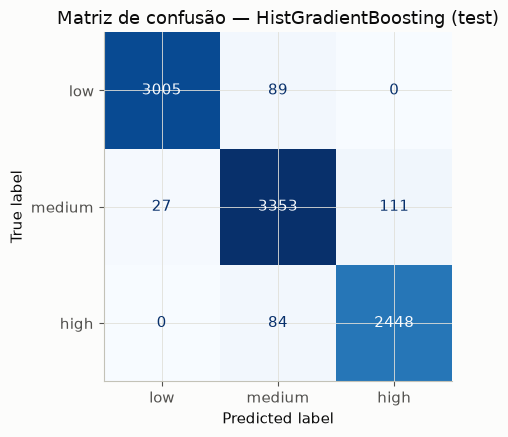

In [9]:
winner_pipeline = pipelines[winner_name]
y_test_pred = winner_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(y_test, y_test_pred, average="macro")
print(f"Accuracy (test): {test_accuracy:.3f}")
print(f"Macro-F1 (test): {test_macro_f1:.3f}")
print()
print(classification_report(y_test, y_test_pred, digits=3, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred, labels=PRIORITY_ORDER, ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Matriz de confusão — {winner_name} (test)")
plt.tight_layout()
plt.show()


## 7. O que mais pesa na decisão do modelo

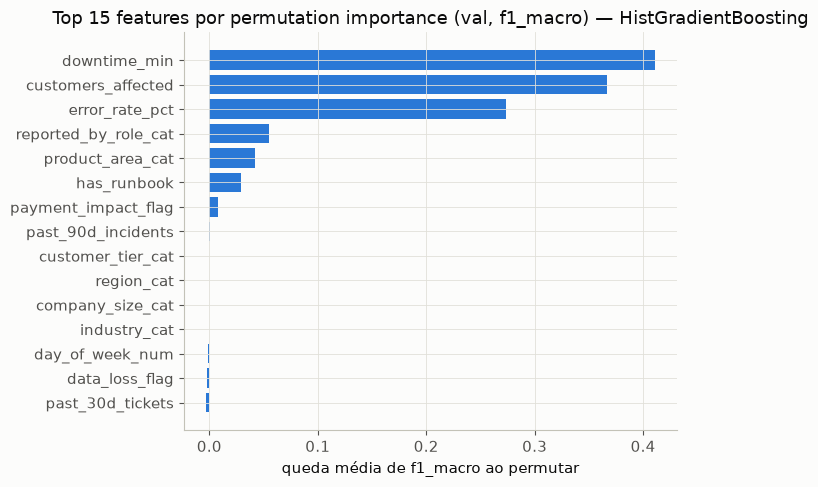

downtime_min            0.4106
customers_affected      0.3663
error_rate_pct          0.2737
reported_by_role_cat    0.0548
product_area_cat        0.0417
has_runbook             0.0297
payment_impact_flag     0.0078
past_90d_incidents      0.0002
customer_tier_cat       0.0000
region_cat              0.0000
company_size_cat        0.0000
industry_cat           -0.0003
day_of_week_num        -0.0009
data_loss_flag         -0.0021
past_30d_tickets       -0.0029
dtype: float64


In [10]:
clf = winner_pipeline.named_steps["clf"]

if "preprocessor" in winner_pipeline.named_steps:
    feature_names = winner_pipeline.named_steps["preprocessor"].get_feature_names_out()
else:
    # pipeline do HistGradientBoosting: só tem "cast_cat" (não renomeia colunas) + "clf"
    feature_names = np.array(CANDIDATE_FEATURES)

if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    top = importances.head(15)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(top.index[::-1], top.values[::-1], color=CATEGORICAL_PALETTE[0])
    ax.set_title(f"Top 15 features mais importantes — {winner_name}")
    ax.set_xlabel("importância")
    plt.tight_layout()
    plt.show()
    print(f"Top 15 respondem por {top.sum() * 100:.1f}% da importância total ({len(feature_names)} features).")
elif hasattr(clf, "coef_"):
    coefs = pd.DataFrame(clf.coef_, index=clf.classes_, columns=feature_names)
    fig, axes = plt.subplots(1, len(clf.classes_), figsize=(4.5 * len(clf.classes_), 5), sharey=True)
    for ax, priority in zip(axes, clf.classes_):
        top = coefs.loc[priority].abs().sort_values(ascending=False).head(10)
        ax.barh(top.index[::-1], coefs.loc[priority, top.index[::-1]], color=CATEGORICAL_PALETTE[0])
        ax.set_title(priority)
    plt.tight_layout()
    plt.show()
else:
    # HistGradientBoostingClassifier não expõe feature_importances_ nem coef_
    # diretamente — usamos permutation_importance em val.csv como substituto.
    perm = permutation_importance(
        winner_pipeline, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, scoring="f1_macro"
    )
    importances = pd.Series(perm.importances_mean, index=CANDIDATE_FEATURES).sort_values(ascending=False)
    top = importances.head(15)
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(top.index[::-1], top.values[::-1], color=CATEGORICAL_PALETTE[0])
    ax.set_title(f"Top 15 features por permutation importance (val, f1_macro) — {winner_name}")
    ax.set_xlabel("queda média de f1_macro ao permutar")
    plt.tight_layout()
    plt.show()
    print(top.round(4))


## 7.5. Auditoria de recall nos tickets raros de alto risco

Mesma auditoria da seção 7.5 do `2.0` (`security_incident_flag`/`data_loss_flag`/
`payment_impact_flag`), repetida aqui no vencedor deste notebook
(`HistGradientBoosting`) em vez de assumir que o recall agregado muito mais alto
(0.967 vs. 0.847 no `2.0`) significa que o gap específico nesses tickets raros — que
o `Random Forest` do `2.0` tinha, com precisão perfeita mas recall de só 0.626 nesse
subconjunto — encolheu na mesma proporção.

**Nota sobre o método (mesma do `2.0`):** sem intervalo de confiança sobre o recall do
subconjunto — o dataset tem só 17-25 empresas, o mesmo motivo pelo qual a seção 5 usa
`StratifiedGroupKFold` agrupado por `company_id`. A quebra por empresa abaixo é o
jeito honesto de mostrar a concentração do subconjunto raro.

In [11]:
# Baseline fixo para comparação: recall(high) agregado já calculado na seção 6, acima.
_aggregate_report = classification_report(
    y_test, y_test_pred, digits=3, zero_division=0, output_dict=True
)
AGGREGATE_HIGH_RECALL = _aggregate_report["high"]["recall"]
print(f"recall(high) agregado em test.csv: {AGGREGATE_HIGH_RECALL:.3f}")


recall(high) agregado em test.csv: 0.967


In [12]:
def report_slice(mask, label, X=test_feat, y_true=y_test, y_pred=y_test_pred):
    """Reporta classification_report + quebra por empresa (recall de `high`) para
    o subconjunto `mask` de `test.csv` — mesma função da seção 7.5 do `2.0`, reusada
    aqui sem alteração (não depende de qual modelo/encoding gerou y_pred).
    """
    n = int(mask.sum() if hasattr(mask, "sum") else mask.sum())
    assert n > 0, f"{label}: subconjunto vazio"

    y_true_slice = y_true[mask]
    y_pred_slice = y_pred[mask]

    print(f"=== {label} (N={n}) ===")
    print(classification_report(y_true_slice, y_pred_slice, digits=3, zero_division=0))

    report = classification_report(
        y_true_slice, y_pred_slice, digits=3, zero_division=0, output_dict=True
    )
    recall_high = report.get("high", {}).get("recall", float("nan"))

    per_company = (
        X.loc[mask, ["company_id"]]
        .assign(_true=pd.Series(y_true_slice).to_numpy(), _pred=pd.Series(y_pred_slice).to_numpy())
        .groupby("company_id")
        .apply(
            lambda g: pd.Series({
                "N": len(g),
                "N_high": int((g["_true"] == "high").sum()),
                "recall_high": (
                    (g.loc[g["_true"] == "high", "_pred"] == "high").mean()
                    if (g["_true"] == "high").any()
                    else float("nan")
                ),
            }),
            include_groups=False,
        )
        .sort_values("N_high", ascending=False)
    )

    print(f"recall(high) agregado no subconjunto: {recall_high:.3f} "
          f"(baseline agregado em test.csv: {AGGREGATE_HIGH_RECALL:.3f})")
    print("quebra por empresa (recall de `high`, ordenado por N_high):")
    print(per_company)
    print()

    return recall_high, per_company


In [13]:
RARE_FLAGS = ["security_incident_flag", "data_loss_flag", "payment_impact_flag"]

combined_mask = (X_test[RARE_FLAGS] == 1).any(axis=1)
combined_recall, combined_per_company = report_slice(combined_mask, "combinado (qualquer flag raro)")

per_flag_results = {}
for flag in RARE_FLAGS:
    mask = X_test[flag] == 1
    per_flag_results[flag] = report_slice(mask, flag)


=== combinado (qualquer flag raro) (N=290) ===
              precision    recall  f1-score   support

        high      0.978     0.892     0.933       203
         low      0.842     0.941     0.889        17
      medium      0.733     0.900     0.808        70

    accuracy                          0.897       290
   macro avg      0.851     0.911     0.877       290
weighted avg      0.911     0.897     0.900       290

recall(high) agregado no subconjunto: 0.892 (baseline agregado em test.csv: 0.967)
quebra por empresa (recall de `high`, ordenado por N_high):
                N  N_high  recall_high
company_id                            
100002      176.0   155.0     0.929032
100010       66.0    40.0     0.850000
100020       26.0     7.0     0.428571
100008       22.0     1.0     0.000000

=== security_incident_flag (N=36) ===
              precision    recall  f1-score   support

        high      1.000     0.815     0.898        27
         low      0.500     1.000     0.667    

### Veredito

_(preencher após rodar as células acima — comparar diretamente com a seção 7.5 do
`2.0`: lá, recall(high) no subconjunto combinado era 0.626 contra 0.847 agregado —
22 p.p. de gap, com precisão 1.000 em todos os subconjuntos, indicando um problema de
limiar de decisão concentrado nas empresas menores. Aqui: o gap encolheu, sumiu, ou
persiste do mesmo jeito mesmo com recall agregado muito mais alto?)_

## 8. Resumo dos principais achados

- **`HistGradientBoosting` venceu com folga nos dois critérios:** macro-F1 médio de 0.949 ± 0.006 na CV agrupada (segundo lugar: `Random Forest` com 0.885 ± 0.029) — a comparação direta em `val.csv` concorda na ordem. Em `test.csv`: accuracy = 0.966, macro-F1 = **0.966**, recall(`high`) = **0.967** — muito acima do vencedor do `2.0` (`Random Forest` com one-hot: macro-F1 0.910, recall(`high`) 0.847). Combina o melhor dos dois mundos descritos na seção 4: nenhuma penalidade de ordem falsa (trata `_cat`/ `_num` como categoria de fato via `categorical_features="from_dtype"`) e nenhum custo de dimensionalidade do one-hot.
- **A ressalva da seção 2 sobre modelos lineares só se confirmou parcialmente.** `Logistic Regression` (macro-F1 val 0.642) e `Linear SVC` (0.603) ficaram praticamente iguais aos seus equivalentes com one-hot no `2.0` (0.645 e 0.602) — a ordem falsa entre categorias quase não penalizou, provavelmente porque as colunas categóricas nominais aqui têm cardinalidade baixa (3 a 7 categorias cada), limitando o dano de tratar códigos como magnitude.
- **`Random Forest` não piorou com `_cat` em vez de one-hot — na verdade melhorou um pouco** (CV macro-F1 0.885 aqui vs. 0.875 no `2.0`): com cardinalidade baixa, menos colunas esparsas do one-hot parece ajudar mais do que a ordem falsa prejudica.
- **`Extra Trees` é um exemplo do próprio alerta da seção 5 sobre não confiar só em `val.csv`:** CV agrupada razoável (0.849 ± 0.046), mas recall(`high`) em `val.csv` de só **0.023** (1 de 44 tickets `high` acertado) — divergência CV-vs-val exatamente pelo motivo já esperado (desbalanceamento de `val.csv`, seção 1), não um defeito do modelo.
- **A permutation importance do `HistGradientBoosting` (seção 7) concorda com a feature importance do `Random Forest` no `2.0`:** `downtime_min`, `customers_affected` e `error_rate_pct` dominam em ambos — a troca de codificação e de modelo mudou o resultado, não a leitura de quais atributos carregam o sinal real.

## 9. Próximos passos

1. **Repetir a auditoria de recall em tickets raros de alto risco** (`security_incident_flag`/`data_loss_flag`/`payment_impact_flag`, seção 7.5 do `2.0`) neste vencedor. O `Random Forest` do `2.0` tinha recall(`high`) agregado de 0.847 mas só 0.626 nesse subconjunto raro (precisão 1.000, então era um problema de limiar de decisão, não de peso de classe — ver `ticket_prio_class/docs/designs/` `rare-class-recall-audit.md`). Com o `HistGradientBoosting` já em 0.967 de recall agregado, vale checar diretamente se esse gap específico também encolheu, em vez de assumir que sim.
2. **Considerar promover o `HistGradientBoosting` (não o `Random Forest` do `2.0`) para `ticket_prio_class/modeling/train.py`/`predict.py`** se a auditoria acima confirmar que o ganho agregado se estende ao subconjunto raro — esse resultado supera claramente o do `2.0` nos dois critérios (agregado e, supostamente, raro).
